# Seasonality in Energy Load

### Imports and Notebook Settings


In [91]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
import os 
import re
from pathlib import Path

In [93]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
# import seaborn as sns 
# import plotly.express as px
import pprint 

In [94]:
ROOT = Path.cwd().parent

In [95]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

In [96]:
DATA_PATH = ROOT / 'data' / 'silver' / 'source=eia930_region' / 'artifact=records'

In [97]:
df = pd.read_parquet(DATA_PATH)

In [98]:
df["observed_at"] = pd.to_datetime(df["observed_at"], utc=True)

In [99]:
wide_df = (
    df.pivot(
        index=["observed_at", "region"],
        columns="variable",
        values="value",
    )
    .reset_index()
    .rename_axis(columns=None)
    .sort_values(["region", "observed_at"])
)

In [100]:
wide_df

,observed_at,region,actual_load,load_forecast,net_generation,total_interchange
0,2019-01-01 00:00:00+00:00,MISO,74304.0,81595.0,70466.0,-5676.0
1,2019-01-01 01:00:00+00:00,MISO,73391.0,80484.0,69693.0,-5428.0
2,2019-01-01 02:00:00+00:00,MISO,71531.0,78470.0,67805.0,-5231.0
3,2019-01-01 03:00:00+00:00,MISO,69562.0,76301.0,66177.0,-4940.0
4,2019-01-01 04:00:00+00:00,MISO,67744.0,73623.0,64142.0,-5035.0
...,...,...,...,...,...,...
66452,2026-07-31 20:00:00+00:00,MISO,103003.0,106141.0,103309.0,-2322.0
66453,2026-07-31 21:00:00+00:00,MISO,103125.0,106814.0,103154.0,-2487.0
66454,2026-07-31 22:00:00+00:00,MISO,102409.0,106965.0,102564.0,-2242.0
66455,2026-07-31 23:00:00+00:00,MISO,100899.0,105986.0,101381.0,-2052.0


In [107]:
wide_df = wide_df.set_index("observed_at")

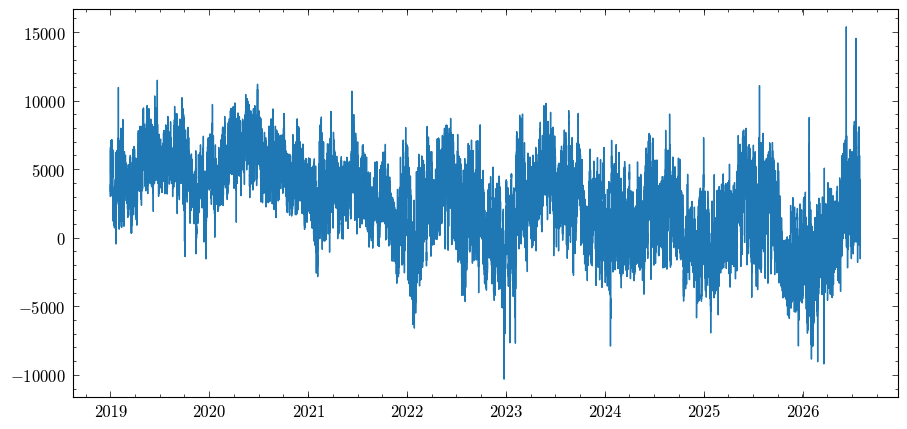

In [124]:
plt.figure(figsize=(10,5))
plt.plot(wide_df['actual_load'] - wide_df['net_generation'])
# plt.plot(wide_df['observed_at'], wide_df['actual_load'])
# plt.plot(wide_df['observed_at'], wide_df['net_generation'])

<Axes: title={'center': 'Daily average load'}, xlabel='observed_at'>

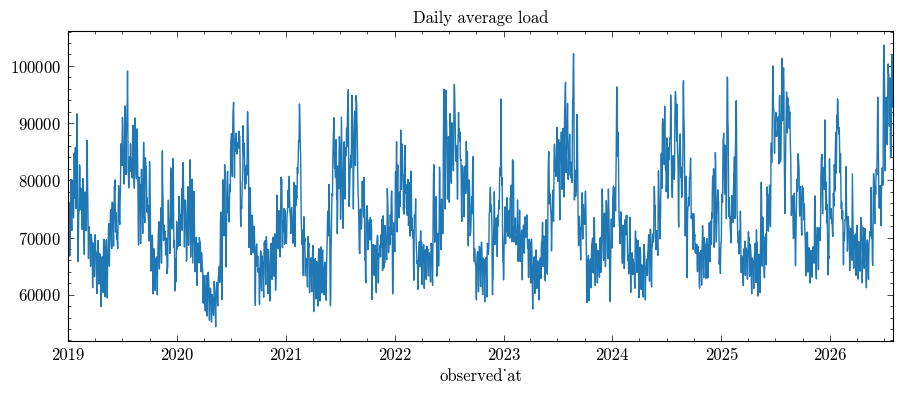

In [112]:
wide_df['actual_load'].resample("D").mean().plot(figsize=(10, 4), title="Daily average load")

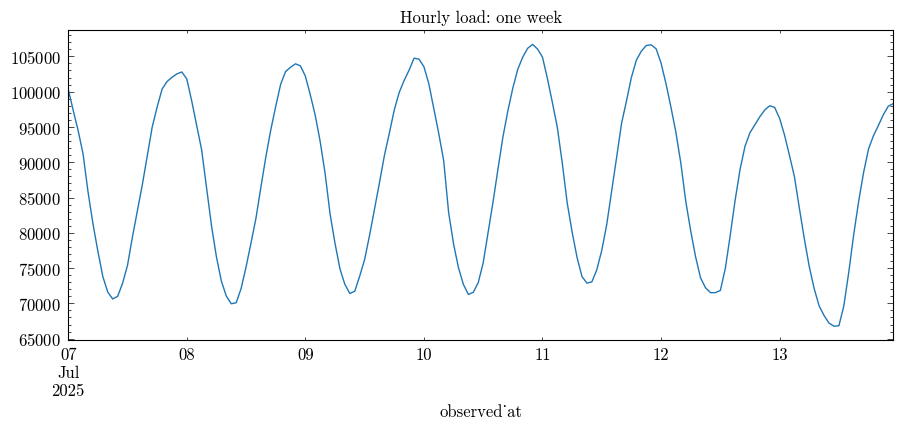

In [123]:
wide_df['actual_load'].loc["2025-07-07":"2025-07-13"].plot(
    figsize=(10, 4),
    title="Hourly load: one week",
)
plt.show()

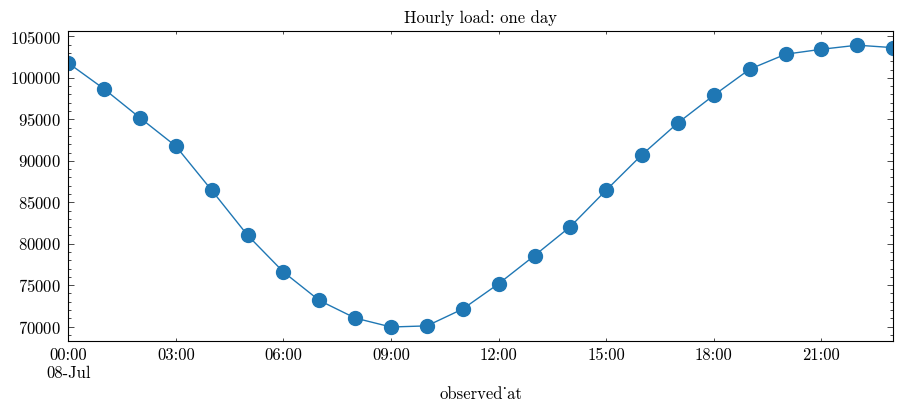

In [118]:
wide_df['actual_load'].loc["2025-07-08"].plot(
    figsize=(10, 4),
    marker="o",
    title="Hourly load: one day",
)
plt.show()

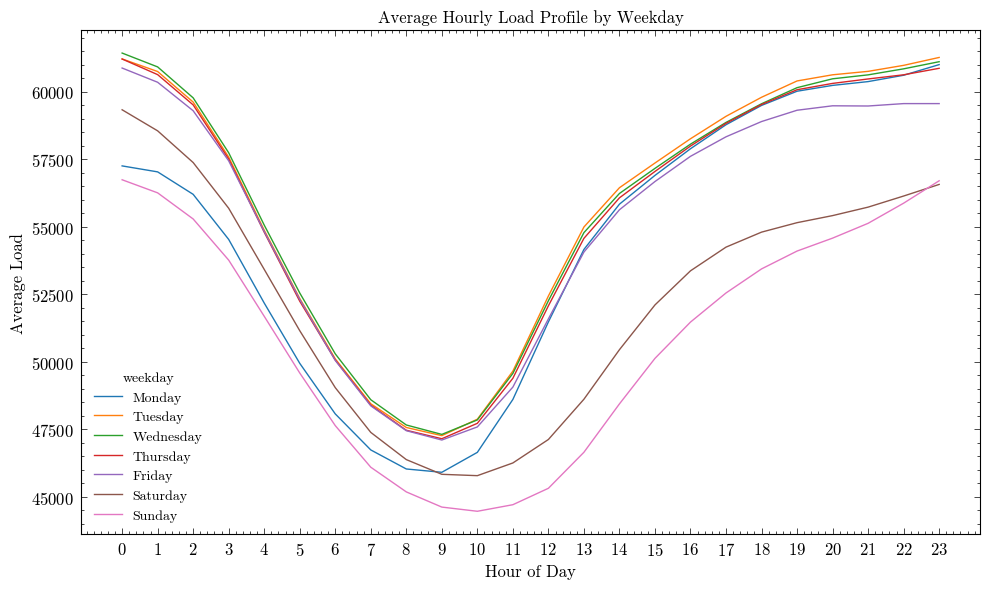

In [125]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

profile = (
    df.assign(
        weekday=df["observed_at"].dt.day_name(),
        hour=df["observed_at"].dt.hour,
    )
    .groupby(["weekday", "hour"])["value"]
    .mean()
    .unstack("weekday")
    .reindex(columns=weekday_order)
)

profile.plot(
    figsize=(10, 6),
    title="Average Hourly Load Profile by Weekday",
    xlabel="Hour of Day",
    ylabel="Average Load",
)

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import periodogram

df["observed_at"] = pd.to_datetime(df["observed_at"])

load = (
    df.set_index("observed_at")["value"]
    .sort_index()
    .resample("h")
    .mean()
    .interpolate(limit_direction="both")
)

In [145]:
frequency, power = periodogram(
    load,
    fs=1,                 # one observation per hour
    detrend="linear",
    scaling="spectrum",
)

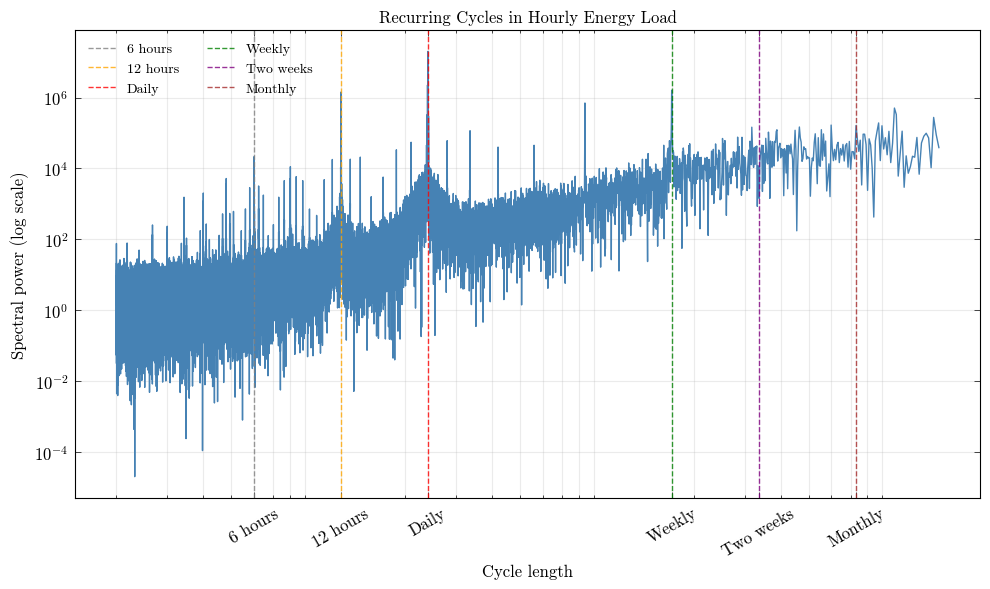

In [150]:
# Remove zero frequency because 1 / 0 is undefined
freq = frequency[1:]
spectral_power = power[1:]
# Convert cycles per hour into cycle length in hours
period_hours = 1 / freq

# Show cycles between 2 hours and 60 days
mask = (period_hours >= 2) & (period_hours <= 24 * 60)

period_hours_plot = period_hours[mask]
power_plot = spectral_power[mask]

# Sort from shorter to longer periods
order = np.argsort(period_hours_plot)
period_hours_plot = period_hours_plot[order]
power_plot = power_plot[order]

plt.figure(figsize=(10, 6))

plt.plot(period_hours_plot, power_plot, color="steelblue")
plt.xscale("log")
plt.yscale("log")

reference_periods = {
    "6 hours": 6,
    "12 hours": 12,
    "Daily": 24,
    "Weekly": 24 * 7,
    "Two weeks": 24 * 14,
    "Monthly": 24 * 30.44,
}

colors = {
    "6 hours": "gray",
    "12 hours": "orange",
    "Daily": "red",
    "Weekly": "green",
    "Two weeks": "purple",
    "Monthly": "brown",
}

for label, period in reference_periods.items():
    plt.axvline(
        period,
        color=colors[label],
        linestyle="--",
        alpha=0.8,
        label=label,
    )

plt.xticks(
    list(reference_periods.values()),
    list(reference_periods.keys()),
    rotation=30,
)

plt.xlabel("Cycle length")
plt.ylabel("Spectral power (log scale)")
plt.title("Recurring Cycles in Hourly Energy Load")
plt.grid(alpha=0.25, which="both")
plt.legend(ncols=2)
plt.tight_layout()
plt.show()